

## Aim
The aim of this project is to develop and evaluate forecasting models for **hourly NO₂ concentrations** at the **London Bloomsbury (CLL2) AURN monitoring site** using historical air-quality time-series data.

## Research Question
**RQ:** How well can we predict next-hour NO₂ at the London Bloomsbury (CLL2) station using historical pollutant measurements, and which method works best: an LSTM, XGBoost, or naive baseline?


## Objectives
1. Collect and clean hourly air-quality data (2015–2025) from DEFRA/UK-AIR.
2. Perform exploratory data analysis (EDA) to understand trends, seasonality, and missingness.
3. Create forecasting datasets using leakage-safe preprocessing (chronological split, train-only scaling).
4. Build and evaluate multiple forecasting models:
   - **Naive baseline** (persistence)
   - **XGBoost regression**
   - **LSTM neural network**
5. Compare models using consistent evaluation metrics (MAE, RMSE) on the same chronological validation and test periods, with an additional aligned-timestamp comparison.
6. Discuss results, limitations, and future improvements.

## Models Compared
We compare the following approaches for the same forecasting task (t+1):

- **Naive persistence baseline:**  
  Predict NO₂(t+1) = NO₂(t)

- **XGBoost (Gradient Boosted Trees):**  
  Supervised learning using engineered lag and rolling-window features

- **LSTM (Recurrent Neural Network):**  
  Sequence learning model using historical time windows of multivariate inputs

## Evaluation Metrics
We evaluate performance using:
- **MAE (Mean Absolute Error)**  
- **RMSE (Root Mean Squared Error)**  

Metrics are reported on:
- Validation set (for hyperparameter selection)
- Test set (final generalization performance)

## Data Split (Chronological)
- **Train:** 2015–2021  
- **Validation:** 2022–2023  
- **Test:** 2024–2025

(Chronological splits are used to avoid data leakage.)

## 1) Imports
This section loads all required Python libraries used throughout the notebook.


In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
!pip install keras-tuner
import keras_tuner as kt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.1 MB/s eta 0:00:00


## 2) Configuration (project settings)
All key parameters (paths, split dates, horizon, window length) are defined here so the notebook is reproducible.

In [ ]:
from pathlib import Path

def _file_path(paths):
    out = []
    for p in paths:
        for candidate in [Path(p), Path("/mnt/data") / Path(p).name, Path.cwd() / Path(p).name]:
            if candidate.exists():
                out.append(str(candidate))
                break
        else:
            out.append(str(Path(p)))
    return out

FILES = _file_path([
    "/content/CLL2_2015.csv",
    "/content/CLL2_2016.csv",
    "/content/CLL2_2017.csv",
    "/content/CLL2_2018.csv",
    "/content/CLL2_2019.csv",
    "/content/CLL2_2020.csv",
    "/content/CLL2_2021.csv",
    "/content/CLL2_2022.csv",
    "/content/CLL2_2023.csv",
    "/content/CLL2_2024.csv",
    "/content/CLL2_2025 (1).csv",
])

SITE_NAME = "London Bloomsbury (CLL2)"
WINDOW = 48     #
HORIZON = 1          # t+1 forecasting
TARGET_COL = "target_t_plus_1"
SHORT_GAP_LIMIT_HOURS = 3

TRAIN_START = "2015-01-01"
TRAIN_END   = "2021-12-31 23:00:00"
VAL_START   = "2022-01-01"
VAL_END     = "2023-12-31 23:00:00"
TEST_START  = "2024-01-01"
TEST_END    = "2025-12-31 23:00:00"

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("files:")
for fp in FILES:
    print(" -", fp)


files:
 - /content/CLL2_2015.csv
 - /content/CLL2_2016.csv
 - /content/CLL2_2017.csv
 - /content/CLL2_2018.csv
 - /content/CLL2_2019.csv
 - /content/CLL2_2020.csv
 - /content/CLL2_2021.csv
 - /content/CLL2_2022.csv
 - /content/CLL2_2023.csv
 - /content/CLL2_2024.csv
 - /content/CLL2_2025 (1).csv


## 3) Data loading and cleaning
Load DEFRA hourly data, fix timestamps, and combine yearly files into one clean hourly dataframe.

In [ ]:
# ============================================================
# 1) DEFRA / UK-AIR LOADING
# ============================================================
def find_header_row(path: str, needle="Date,time") -> int:
    with open(path, "r", encoding="utf-8-sig", errors="replace") as f:
        for i, line in enumerate(f):
            if line.strip().startswith(needle):
                return i
    raise ValueError(f"Could not find header row in {path}")

def load_ukair_csv(path: str, hour_ending: bool = True) -> pd.DataFrame:
    header_row = find_header_row(path)

    df = pd.read_csv(
        path,
        skiprows=header_row,
        encoding="utf-8-sig",
        engine="python",
        skip_blank_lines=True,
        on_bad_lines="warn",
    )
    df.columns = [str(c).strip() for c in df.columns]

    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

    t = df["time"].astype(str).str.strip()
    is24 = t.eq("24:00")
    t = t.mask(is24, "00:00")

    dt = pd.to_datetime(df["Date"].dt.strftime("%Y-%m-%d") + " " + t, errors="coerce")
    dt = dt + pd.to_timedelta(is24.astype(int), unit="D")

    # hour-ending -> hour-start
    if hour_ending:
        dt = dt - pd.Timedelta(hours=1)

    df.insert(0, "datetime", dt)
    df = df.drop(columns=["Date", "time"], errors="ignore")
    df = df.dropna(subset=["datetime"]).sort_values("datetime")
    df = df.drop_duplicates(subset=["datetime"], keep="last")
    df = df.set_index("datetime").sort_index()

    return df.asfreq("h")

def load_all_files(files, hour_ending=True) -> pd.DataFrame:
    dfs = []
    for fp in files:
        if Path(fp).exists():
            print("Loading:", Path(fp).name)
            dfs.append(load_ukair_csv(fp, hour_ending=hour_ending))
        else:
            print("Missing:", fp)

    if not dfs:
        raise ValueError("No files loaded. Check paths.")

    df_all = pd.concat(dfs, axis=0, sort=False).sort_index()
    df_all = df_all[~df_all.index.duplicated(keep="last")].sort_index()
    return df_all.asfreq("h")

## 4) Load and unify yearly datasets (2015–2025)

In [ ]:
df_all = load_all_files(FILES, hour_ending=True)
print("\n=== df_all ===")
print("Shape:", df_all.shape)
print("Range:", df_all.index.min(), "->", df_all.index.max())

Loading: CLL2_2015.csv
Loading: CLL2_2016.csv
Loading: CLL2_2017.csv
Loading: CLL2_2018.csv
Loading: CLL2_2019.csv
Loading: CLL2_2020.csv
Loading: CLL2_2021.csv
Loading: CLL2_2022.csv
Loading: CLL2_2023.csv
Loading: CLL2_2024.csv
Loading: CLL2_2025 (1).csv

=== df_all ===
Shape: (96432, 33)
Range: 2015-01-01 00:00:00 -> 2025-12-31 23:00:00


## 5) Build modelling dataframe (pollutants + time features)
Create the core modelling variables (NO₂, NO, NOx, O₃) and time-based features used in later EDA and modelling.

In [ ]:
# ============================================================
# 2) BUILD RAW POLLUTANTS + TIME FEATURES
# ============================================================
COL_NO2 = "Nitrogen dioxide"
COL_NO  = "Nitric oxide"
COL_NOX = "Nitrogen oxides as nitrogen dioxide"
COL_O3  = "Ozone"

missing_cols = [c for c in [COL_NO2, COL_NO, COL_NOX, COL_O3] if c not in df_all.columns]
if missing_cols:
    print("Available columns (first 100):")
    print(df_all.columns.tolist()[:100])
    raise ValueError(f"Missing AQ columns: {missing_cols}")

base = pd.DataFrame(index=df_all.index)
base["no2"] = pd.to_numeric(df_all[COL_NO2], errors="coerce")
base["no"]  = pd.to_numeric(df_all[COL_NO],  errors="coerce")
base["nox"] = pd.to_numeric(df_all[COL_NOX], errors="coerce")
base["o3"]  = pd.to_numeric(df_all[COL_O3],  errors="coerce")

# time features
base["hour"] = base.index.hour
base["dayofweek"] = base.index.dayofweek
base["month"] = base.index.month
base["is_weekend"] = (base["dayofweek"] >= 5).astype(int)

base["hour_sin"]  = np.sin(2*np.pi*base["hour"]/24)
base["hour_cos"]  = np.cos(2*np.pi*base["hour"]/24)
base["dow_sin"]   = np.sin(2*np.pi*base["dayofweek"]/7)
base["dow_cos"]   = np.cos(2*np.pi*base["dayofweek"]/7)
base["month_sin"] = np.sin(2*np.pi*(base["month"]-1)/12)
base["month_cos"] = np.cos(2*np.pi*(base["month"]-1)/12)

## 5) Exploratory Data Analysis (EDA)
We explore the dataset to understand missingness, trends, seasonality, and pollutant relationships. These findings guide preprocessing (gap handling) and feature engineering for forecasting models.



EDA range: 2015-01-01 00:00:00 -> 2025-12-31 23:00:00
Core columns: ['no2', 'no', 'nox', 'o3']


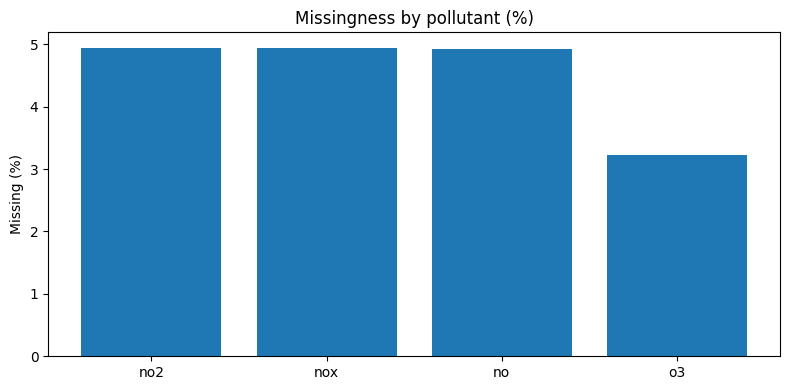

Missingness (%):
 no2    4.94
nox    4.94
no     4.93
o3     3.22
dtype: float64


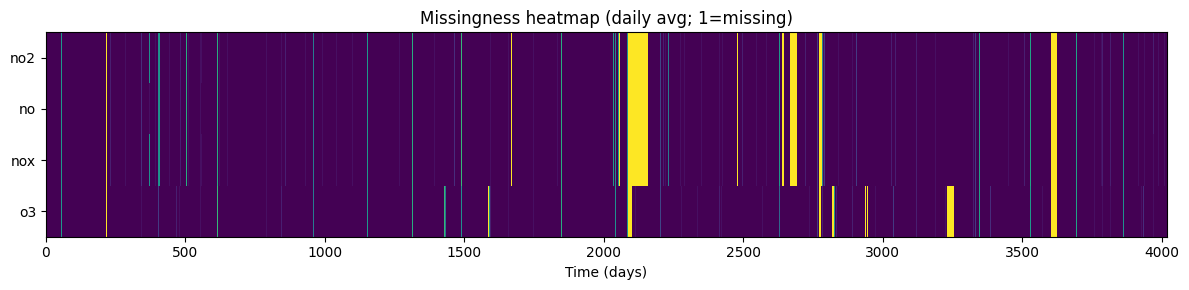

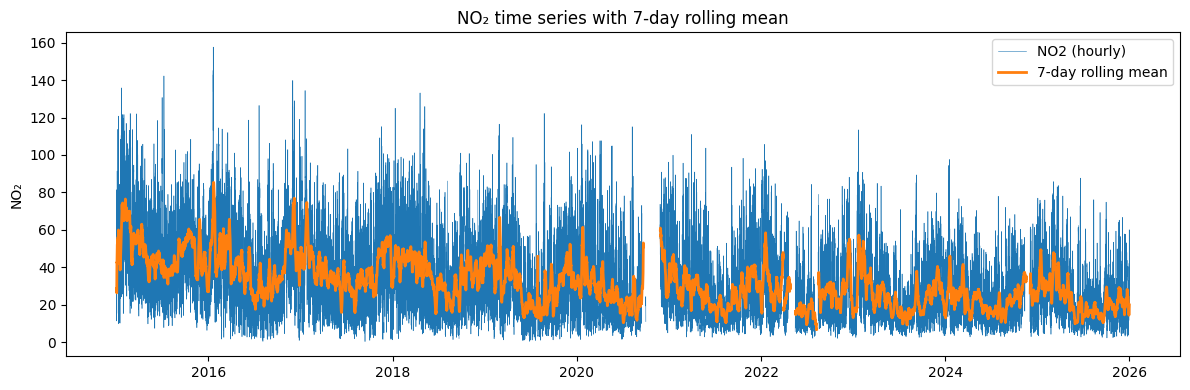

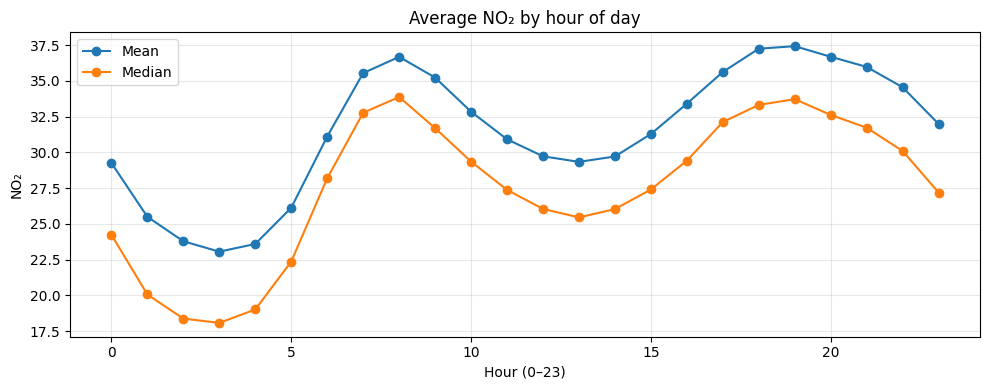

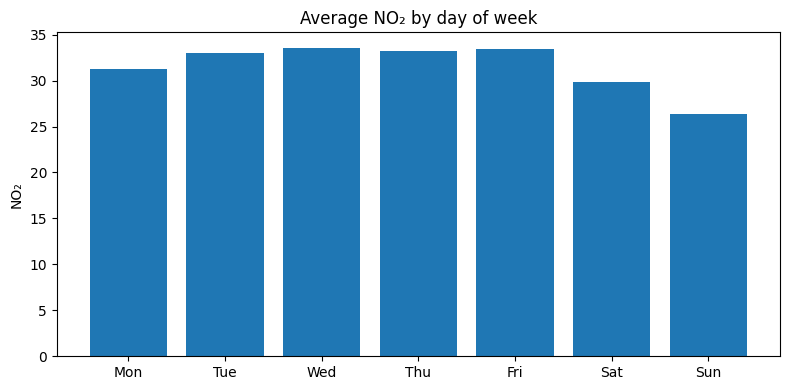

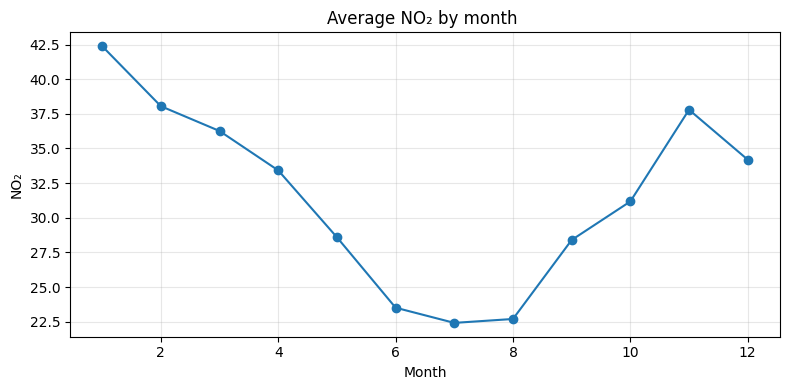

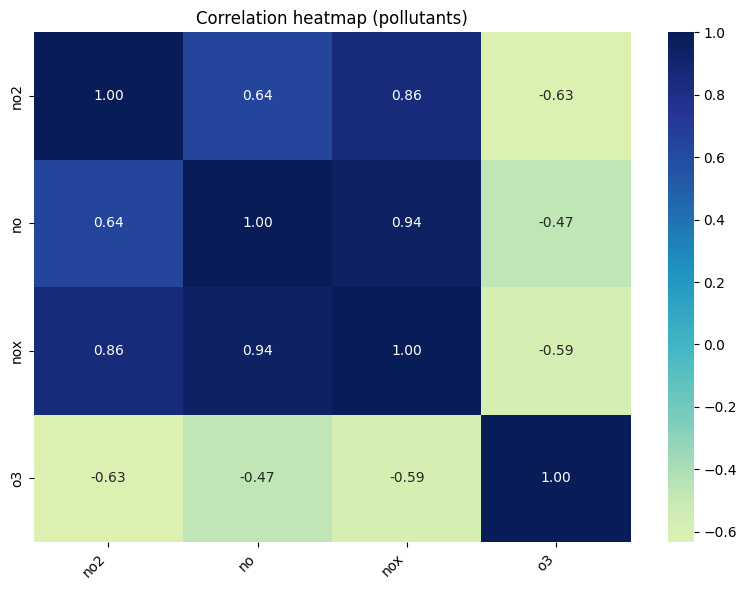

Correlation matrix:
        no2     no    nox     o3
no2  1.000  0.641  0.857 -0.633
no   0.641  1.000  0.945 -0.471
nox  0.857  0.945  1.000 -0.586
o3  -0.633 -0.471 -0.586  1.000


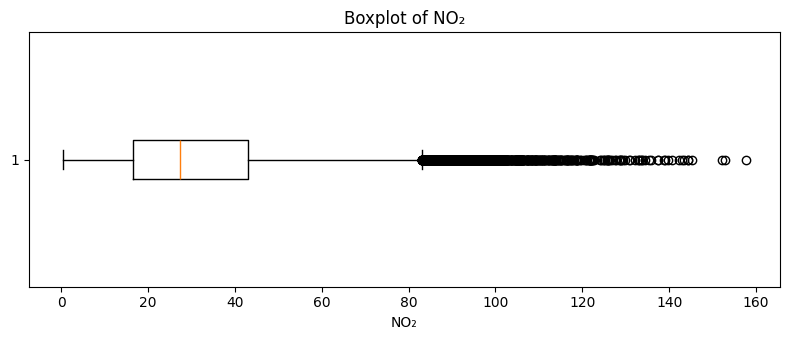

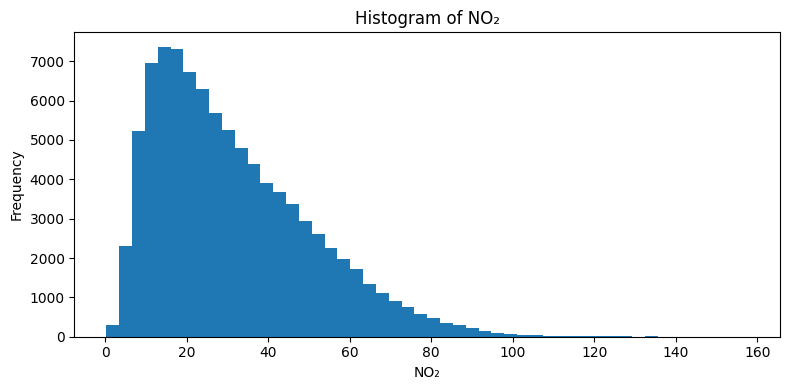

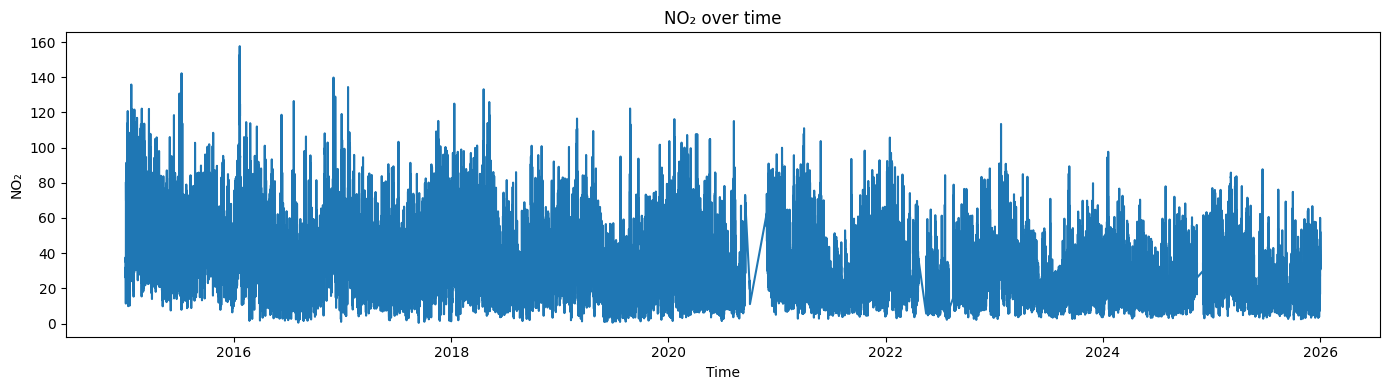

NO₂ IQR lower bound: -23.57
NO₂ IQR upper bound: 83.08
Number of IQR-flagged values: 1329


,no2
datetime,
2015-01-03 21:00:00,91.39790
2015-01-03 22:00:00,89.76414
2015-01-04 01:00:00,84.04928
2015-01-06 16:00:00,92.42682
2015-01-06 17:00:00,113.72442
2015-01-06 18:00:00,101.28170
2015-01-06 19:00:00,101.17794
2015-01-06 20:00:00,90.68549
2015-01-06 21:00:00,86.31591



99th percentile of NO₂: 87.10
Number of values in top 1%: 917


,no2
datetime,
2015-01-03 21:00:00,91.39790
2015-01-03 22:00:00,89.76414
2015-01-06 16:00:00,92.42682
2015-01-06 17:00:00,113.72442
2015-01-06 18:00:00,101.28170
2015-01-06 19:00:00,101.17794
2015-01-06 20:00:00,90.68549
2015-01-08 09:00:00,113.04692
2015-01-08 10:00:00,112.46504


In [ ]:
# ============================================================
# EDA
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

eda = base.copy().sort_index()
core_cols = [c for c in ["no2", "no", "nox", "o3"] if c in eda.columns]

print("EDA range:", eda.index.min(), "->", eda.index.max())
print("Core columns:", core_cols)

# ------------------------------------------------------------
# 1) Missingness % per pollutant
# ------------------------------------------------------------
missing_pct = (eda[core_cols].isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(missing_pct.index, missing_pct.values)
plt.title("Missingness by pollutant (%)")
plt.ylabel("Missing (%)")
plt.tight_layout()
plt.show()

print("Missingness (%):\n", missing_pct.round(2))

# ------------------------------------------------------------
# 2) Missingness heatmap over time (daily average)
# ------------------------------------------------------------
miss_map = eda[core_cols].isna().astype(int)
miss_daily = miss_map.resample("D").mean()

plt.figure(figsize=(12,3))
plt.imshow(miss_daily.T, aspect="auto", interpolation="nearest")
plt.yticks(range(len(core_cols)), core_cols)
plt.title("Missingness heatmap (daily avg; 1=missing)")
plt.xlabel("Time (days)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3) NO2 time series + 7-day rolling mean (raw)
# ------------------------------------------------------------
if "no2" in eda.columns:
    plt.figure(figsize=(12,4))
    plt.plot(eda.index, eda["no2"], linewidth=0.4, label="NO2 (hourly)")
    plt.plot(eda["no2"].rolling(24*7, min_periods=24).mean(), linewidth=2, label="7-day rolling mean")
    plt.title("NO₂ time series with 7-day rolling mean")
    plt.ylabel("NO₂")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 4) Seasonality: average NO2 by hour-of-day
# ------------------------------------------------------------
if "no2" in eda.columns:
    tmp = eda[["no2"]].dropna().copy()
    tmp["hour"] = tmp.index.hour
    hour_mean = tmp.groupby("hour")["no2"].mean()
    hour_med  = tmp.groupby("hour")["no2"].median()

    plt.figure(figsize=(10,4))
    plt.plot(hour_mean.index, hour_mean.values, marker="o", label="Mean")
    plt.plot(hour_med.index,  hour_med.values,  marker="o", label="Median")
    plt.title("Average NO₂ by hour of day")
    plt.xlabel("Hour (0–23)")
    plt.ylabel("NO₂")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 5) Seasonality: average NO2 by day-of-week
# ------------------------------------------------------------
if "no2" in eda.columns:
    tmp = eda[["no2"]].dropna().copy()
    tmp["dow"] = tmp.index.dayofweek  # 0=Mon ... 6=Sun
    dow_mean = tmp.groupby("dow")["no2"].mean()

    dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

    plt.figure(figsize=(8,4))
    plt.bar(range(7), dow_mean.values)
    plt.xticks(range(7), dow_labels)
    plt.title("Average NO₂ by day of week")
    plt.ylabel("NO₂")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6) Seasonality: average NO2 by month
# ------------------------------------------------------------
if "no2" in eda.columns:
    tmp = eda[["no2"]].dropna().copy()
    tmp["month"] = tmp.index.month
    month_mean = tmp.groupby("month")["no2"].mean()

    plt.figure(figsize=(8,4))
    plt.plot(month_mean.index, month_mean.values, marker="o")
    plt.title("Average NO₂ by month ")
    plt.xlabel("Month")
    plt.ylabel("NO₂")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 7) Correlation heatmap (pollutants) - Seaborn Version
# ------------------------------------------------------------
corr_df = eda[core_cols].dropna()
corr = corr_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True, fmt=".2f", cmap='YlGnBu', center=0)

plt.title("Correlation heatmap (pollutants)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Correlation matrix:\n", corr.round(3))

# outlier
# ============================================================
# EDA: Outlier inspection for NO2
# ============================================================
# Replace eda_df with the dataframe you are using in EDA if needed.
# It should contain a datetime index and a 'no2' column.

# ------------------------------------------------------------
# 8) Outlier inspection: NO2
# ------------------------------------------------------------
eda_df = eda.copy()
no2_series = eda_df["no2"].dropna()

# 1) Boxplot
plt.figure(figsize=(8, 3.5))
plt.boxplot(no2_series, vert=False)
plt.title("Boxplot of NO₂")
plt.xlabel("NO₂")
plt.tight_layout()
plt.show()

# 2) Histogram
plt.figure(figsize=(8, 4))
plt.hist(no2_series, bins=50)
plt.title("Histogram of NO₂")
plt.xlabel("NO₂")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 3) Full time-series plot
plt.figure(figsize=(14, 4))
plt.plot(no2_series.index, no2_series.values)
plt.title("NO₂ over time")
plt.xlabel("Time")
plt.ylabel("NO₂")
plt.tight_layout()
plt.show()

# 4) IQR-based flagging (inspection only)
q1 = no2_series.quantile(0.25)
q3 = no2_series.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

iqr_outliers = eda_df[(eda_df["no2"] < lower_bound) | (eda_df["no2"] > upper_bound)]

print(f"NO₂ IQR lower bound: {lower_bound:.2f}")
print(f"NO₂ IQR upper bound: {upper_bound:.2f}")
print(f"Number of IQR-flagged values: {len(iqr_outliers)}")

display(iqr_outliers[["no2"]].head(10))

# 5) Top 1% extreme values
q99 = no2_series.quantile(0.99)
extreme_no2 = eda_df[eda_df["no2"] >= q99].copy()

print(f"\n99th percentile of NO₂: {q99:.2f}")
print(f"Number of values in top 1%: {len(extreme_no2)}")

display(extreme_no2[["no2"]].head(10))


## 6) Preprocessing
We apply short-gap imputation (forward fill up to 3 hours), define the forecast target, and create **strict chronological origin-based splits** before model-specific feature engineering and train-only scaling.

Two safeguards are implemented here:

1. **No future-looking imputation**: short gaps are filled using past observations only.
2. **No split-boundary label leakage**: train/validation/test splits are defined on forecast origins, so each split only uses targets that belong to the same time period.


### 6.1 Missing data handling (causal short-gap fill)
To avoid look-ahead leakage, raw pollutant series are imputed using a **forward fill limited to short gaps (≤ 3 hours)**. Longer gaps remain missing and are handled later by dropping affected rows/windows during feature construction.




In [ ]:
# short-gap imputation on raw pollutants only
base_filled = base.copy()
pollutants = ["no2", "no", "nox", "o3"]

missing_before = (base[pollutants].isna().mean() * 100).round(2)
base_filled[pollutants] = base_filled[pollutants].ffill(limit=SHORT_GAP_LIMIT_HOURS)
missing_after = (base_filled[pollutants].isna().mean() * 100).round(2)

missingness_summary = pd.DataFrame({
    "missing_before_pct": missing_before,
    "missing_after_pct": missing_after,
    "filled_pct_points": (missing_before - missing_after).round(2),
})
print("\nMissingness summary after causal short-gap fill (%):")
display(missingness_summary)



Missingness summary after causal short-gap fill (%):


,missing_before_pct,missing_after_pct,filled_pct_points
no2,4.94,4.49,0.45
no,4.93,4.48,0.45
nox,4.94,4.49,0.45
o3,3.22,2.87,0.35


### 6.2 Forecast target definition
The supervised target is **NO₂ at time t+1**. Features are built from information available up to and including time **t**, while the target comes from the **next hour**.

Importantly, the target is derived from the  observed NO₂ series**, not the imputed feature series, so evaluation remains anchored to actual measurements.


In [ ]:
# Model table used for feature engineering:
# - predictors come from the filled feature table
# - target comes from the observed NO2 series shifted by +1 hour
base_model = base_filled.copy()
base_model[TARGET_COL] = base["no2"].shift(-HORIZON)

print("\nTarget missingness (%):", round(base_model[TARGET_COL].isna().mean() * 100, 2))



Target missingness (%): 4.94


### 6.3 Chronological splitting (forecast-origin based)
Splits are defined on the **forecast origin timestamp** rather than the raw series alone.  
For a t+1 task, the last valid origin in each split is shifted back by 1 hour so that training, validation, and test labels do not cross into the next split.


In [ ]:
TRAIN_END_TS = pd.Timestamp(TRAIN_END)
VAL_END_TS   = pd.Timestamp(VAL_END)
TEST_END_TS  = pd.Timestamp(TEST_END)

TRAIN_ORIGIN_END = TRAIN_END_TS - pd.Timedelta(hours=HORIZON)
VAL_ORIGIN_END   = VAL_END_TS   - pd.Timedelta(hours=HORIZON)
TEST_ORIGIN_END  = TEST_END_TS  - pd.Timedelta(hours=HORIZON)

TRAIN_IDX = base_model.loc[TRAIN_START:TRAIN_ORIGIN_END].index
VAL_IDX   = base_model.loc[VAL_START:VAL_ORIGIN_END].index
TEST_IDX  = base_model.loc[TEST_START:TEST_ORIGIN_END].index

def split_any(df: pd.DataFrame):
    train = df.loc[df.index.intersection(TRAIN_IDX)].copy()
    val   = df.loc[df.index.intersection(VAL_IDX)].copy()
    test  = df.loc[df.index.intersection(TEST_IDX)].copy()
    return train, val, test

print("\nForecast-origin split sizes (hours):", len(TRAIN_IDX), len(VAL_IDX), len(TEST_IDX))
print("Train origins:", TRAIN_IDX.min(), "->", TRAIN_IDX.max())
print("Val origins  :", VAL_IDX.min(),   "->", VAL_IDX.max())
print("Test origins :", TEST_IDX.min(),  "->", TEST_IDX.max())



Forecast-origin split sizes (hours): 61367 17519 17543
Train origins: 2015-01-01 00:00:00 -> 2021-12-31 22:00:00
Val origins  : 2022-01-01 00:00:00 -> 2023-12-31 22:00:00
Test origins : 2024-01-01 00:00:00 -> 2025-12-31 22:00:00


### 6.4 LSTM feature engineering (clean sequence model)
LSTM now consumes a **cleaner sequence input** that ends at the current forecast origin (**time t**), so the last row in each input window is the latest information available before predicting **NO₂ at t+1**.

To avoid over-engineering the deep model, the LSTM feature set is intentionally restricted to:

- **pollutants:** `no2`, `no`, `nox`, `o3`
- **Calendar / cyclical time encodings:** `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `month_sin`, `month_cos`, `is_weekend`

This keeps the LSTM conceptually cleaner than the tabular XGBoost setup: the sequence model learns temporal structure from the ordered history itself rather than from manually injected lag, rolling, and differenced features.


In [ ]:
# ============================================================
# 6A) LSTM FEATURE ENGINEERING
# ============================================================
lstm_df = base_model.copy()

# Keep the deep-learning input deliberately simple:
# pollutant history + cyclical/calendar context only.
LSTM_FEATURE_COLS = [
    "no2", "no", "nox", "o3",
    "is_weekend",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
]

lstm_forecast_df = lstm_df[LSTM_FEATURE_COLS + [TARGET_COL]].copy()

train_lstm_df, val_lstm_df, test_lstm_df = split_any(lstm_forecast_df)

print("LSTM feature columns:")
print(LSTM_FEATURE_COLS)
print("\nLSTM split shapes:")
print("Train:", train_lstm_df.shape, " Val:", val_lstm_df.shape, " Test:", test_lstm_df.shape)


LSTM feature columns:
['no2', 'no', 'nox', 'o3', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

LSTM split shapes:
Train: (61367, 12)  Val: (17519, 12)  Test: (17543, 12)


### 6.5 XGBoost feature engineering
Creating Lag features, rolling statistics, differences, and time encoding for Xgboost :
- **Lag features:** lag1…lag48 for each pollutant (no2, no, nox, o3)
- **Rolling statistics (NO₂):** rolling mean (3, 6, 24) and rolling std (24)
- **Differences (NO₂):** diff1 and diff24
- **Time encodings:** hour_sin/cos, dow_sin/cos, month_sin/cos, is_weekend

The code cell below constructs a supervised table used to train the XGBoost model. Feature generation uses only current/past information.


In [ ]:
# ============================================================
# 6B) XGBOOST FEATURE ENGINEERING (wide lag table) -> supervised table
# ============================================================
xgb_df = base_model.copy()

MAX_LAG = 48
lag_base_cols = ["no2", "no", "nox", "o3"]

lag_frames = []
for c in lag_base_cols:
    lag_frames.append(
        pd.DataFrame(
            {f"{c}_lag{lag}": xgb_df[c].shift(lag) for lag in range(1, MAX_LAG + 1)},
            index=xgb_df.index
        )
    )

xgb_df = pd.concat([xgb_df] + lag_frames, axis=1)

# Rolling stats
xgb_df["no2_roll_mean_3"]  = xgb_df["no2"].rolling(3).mean()
xgb_df["no2_roll_mean_6"]  = xgb_df["no2"].rolling(6).mean()
xgb_df["no2_roll_mean_24"] = xgb_df["no2"].rolling(24).mean()
xgb_df["no2_roll_std_24"]  = xgb_df["no2"].rolling(24).std()

# Differences
xgb_df["no2_diff1"]  = xgb_df["no2"] - xgb_df["no2"].shift(1)
xgb_df["no2_diff24"] = xgb_df["no2"] - xgb_df["no2"].shift(24)

time_cols = ["is_weekend","hour_sin","hour_cos","dow_sin","dow_cos","month_sin","month_cos"]
eng_cols  = ["no2_roll_mean_3","no2_roll_mean_6","no2_roll_mean_24","no2_roll_std_24","no2_diff1","no2_diff24"]
lag_cols  = [c for c in xgb_df.columns if "_lag" in c]

XGB_FEATURE_COLS = lag_cols + eng_cols + time_cols

# Supervised table for XGBoost: drop rows with NaNs from lags/rollings/target
sup = xgb_df[XGB_FEATURE_COLS + [TARGET_COL]].dropna().copy()

train_sup, val_sup, test_sup = split_any(sup)

X_train_xgb, y_train_xgb = train_sup[XGB_FEATURE_COLS], train_sup[TARGET_COL]
X_val_xgb,   y_val_xgb   = val_sup[XGB_FEATURE_COLS],   val_sup[TARGET_COL]
X_test_xgb,  y_test_xgb  = test_sup[XGB_FEATURE_COLS],  test_sup[TARGET_COL]

print("\n=== XGBoost splits (common split_any) ===")
print("Train:", X_train_xgb.shape, X_train_xgb.index.min(), "->", X_train_xgb.index.max())
print("Val  :", X_val_xgb.shape,   X_val_xgb.index.min(),   "->", X_val_xgb.index.max())
print("Test :", X_test_xgb.shape,  X_test_xgb.index.min(),  "->", X_test_xgb.index.max())

print("\nNOTE:")
print("- Splitting is defined ONCE (TRAIN_IDX / VAL_IDX / TEST_IDX + split_any).")
print("- Row counts still differ across models because lag/rolling features (XGBoost)")
print("  and sequence windows (LSTM) remove different timestamps.")



=== XGBoost splits (common split_any) ===
Train: (56172, 205) 2015-01-03 00:00:00 -> 2021-12-31 22:00:00
Val  : (14462, 205) 2022-01-01 00:00:00 -> 2023-12-31 22:00:00
Test : (16432, 205) 2024-01-01 00:00:00 -> 2025-12-31 22:00:00

NOTE:
- Splitting is defined ONCE (TRAIN_IDX / VAL_IDX / TEST_IDX + split_any).
- Row counts still differ across models because lag/rolling features (XGBoost)
  and sequence windows (LSTM) remove different timestamps.


## 7) Baseline model (naive persistence)
We use a simple persistence baseline for comparison: predict the next NO₂ value as the most recent available value, i.e. **NO₂(t+1) = NO₂(t)**. This is a strong short-horizon benchmark and sets the minimum performance level that more complex models should beat.


In [ ]:
# ============================================================
# 7) BASELINE: Naive Persistence (t+1)
#    y_hat(t+1) = NO2(t)
# ============================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

baseline_df = pd.DataFrame(index=base_model.index)
baseline_df["y_true"] = base_model[TARGET_COL]
baseline_df["y_pred_naive"] = base_model["no2"]

val_baseline  = baseline_df.loc[baseline_df.index.intersection(VAL_IDX)].dropna().copy()
test_baseline = baseline_df.loc[baseline_df.index.intersection(TEST_IDX)].dropna().copy()

val_mae, val_rmse   = reg_metrics(val_baseline["y_true"], val_baseline["y_pred_naive"])
test_mae, test_rmse = reg_metrics(test_baseline["y_true"], test_baseline["y_pred_naive"])

print("\n=== NAIVE baseline (t+1) ===")
print(f"Validation MAE : {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test MAE       : {test_mae:.4f}")
print(f"Test RMSE      : {test_rmse:.4f}")



=== NAIVE baseline (t+1) ===
Validation MAE : 4.0436
Validation RMSE: 6.0033
Test MAE       : 3.6270
Test RMSE      : 5.3670


## 8 XGBOOST MODEL



In [ ]:
# ============================================================
# 8.1 Convert data to XGBoost DMatrix
# ============================================================
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("xgboost version:", xgb.__version__)

def reg_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

dtrain = xgb.DMatrix(X_train_xgb, label=y_train_xgb)
dval   = xgb.DMatrix(X_val_xgb,   label=y_val_xgb)
dtest  = xgb.DMatrix(X_test_xgb,  label=y_test_xgb)


xgboost version: 3.2.0


## 8.2 Stage A: Fast Hyperparameter search

In [ ]:
# ============================================================
# 8.2 STAGE A: Fast tuning
# ============================================================

rng = np.random.default_rng(42)

FAST_TRIALS = 12
FAST_NUM_BOOST_ROUND = 1500
FAST_EARLY_STOP = 50
# defining parameters for the model
def sample_params_fast(rng):
    return {
        "learning_rate": float(rng.choice([0.03, 0.05])),
        "max_depth": int(rng.integers(3, 8)),
        "min_child_weight": float(rng.choice([1, 2, 3, 5])),
        "subsample": float(rng.choice([0.7, 0.85, 1.0])),
        "colsample_bytree": float(rng.choice([0.7, 0.85, 1.0])),
        "colsample_bynode": float(rng.choice([0.7, 0.9, 1.0])),
        "gamma": float(rng.choice([0.0, 0.05, 0.1, 0.3])),
        "reg_alpha": float(rng.choice([0.0, 0.01, 0.1, 0.5])),
        "reg_lambda": float(rng.choice([1.0, 2.0, 5.0])),
    }

### 8.3 Training Function

In [ ]:
# defining the early_stop
def train_with_early_stop_mae(params, num_boost_round, early_stopping_rounds):

    xgb_params = {
        "objective": "reg:squarederror",
        "eval_metric": "mae",  # early stopping based on MAE
        "tree_method": "hist",
        "seed": 42,
        "verbosity": 0,
        **params,
    }

    evals_result = {}

    booster = xgb.train(
        params=xgb_params,
        dtrain=dtrain,
        num_boost_round=num_boost_round,
        evals=[(dtrain, "train"), (dval, "val")],
        early_stopping_rounds=early_stopping_rounds,
        evals_result=evals_result,
        verbose_eval=False
    )

    return booster, evals_result

### 8.4 Run stage A Search

In [ ]:
# ============================================================
# 8.4 Run Stage A search
# ============================================================
# searching the best parameters for the model
best = {
    "val_mae": np.inf,
    "val_rmse": None,
    "params": None,
    "best_iter": None,
    "booster": None
}

print("\n=== STAGE A: Fast tuning ===")

for i in range(1, FAST_TRIALS + 1):
    params = sample_params_fast(rng)
    booster, _ = train_with_early_stop_mae(params, FAST_NUM_BOOST_ROUND, FAST_EARLY_STOP)

    pred_val_stage_a = booster.predict(dval)
    val_mae_stage_a, val_rmse_stage_a = reg_metrics(y_val_xgb, pred_val_stage_a)
    best_iter = booster.best_iteration

    if val_mae_stage_a < best["val_mae"]:
        best.update({
            "val_mae": val_mae_stage_a,
            "val_rmse": val_rmse_stage_a,
            "params": params,
            "best_iter": best_iter,
            "booster": booster
        })

    print(f"Trial {i:02d} | val MAE={val_mae_stage_a:.4f} RMSE={val_rmse_stage_a:.4f} | best_iter={best_iter}")

print("\nBest Stage A:")
print("val MAE :", round(best["val_mae"], 4))
print("val RMSE:", round(best["val_rmse"], 4))
print("params  :", best["params"])
print("best_iter:", best["best_iter"])



=== STAGE A: Fast tuning ===
Trial 01 | val MAE=3.7479 RMSE=5.5304 | best_iter=214
Trial 02 | val MAE=3.7766 RMSE=5.5527 | best_iter=287
Trial 03 | val MAE=3.7662 RMSE=5.5387 | best_iter=168
Trial 04 | val MAE=3.7732 RMSE=5.5493 | best_iter=203
Trial 05 | val MAE=3.7805 RMSE=5.5529 | best_iter=126
Trial 06 | val MAE=3.7816 RMSE=5.5558 | best_iter=218
Trial 07 | val MAE=3.8285 RMSE=5.5970 | best_iter=519
Trial 08 | val MAE=3.7688 RMSE=5.5518 | best_iter=155
Trial 09 | val MAE=3.8072 RMSE=5.5753 | best_iter=686
Trial 10 | val MAE=3.8148 RMSE=5.5855 | best_iter=625
Trial 11 | val MAE=3.7571 RMSE=5.5344 | best_iter=211
Trial 12 | val MAE=3.7580 RMSE=5.5329 | best_iter=220

Best Stage A:
val MAE : 3.7479
val RMSE: 5.5304
params  : {'learning_rate': 0.03, 'max_depth': 6, 'min_child_weight': 3.0, 'subsample': 0.85, 'colsample_bytree': 0.85, 'colsample_bynode': 1.0, 'gamma': 0.0, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
best_iter: 214


### Stage B: Final training

In [ ]:
# ============================================================
# 8.5 STAGE B: Final training
# ============================================================
FINAL_NUM_BOOST_ROUND = 6000
FINAL_EARLY_STOP = 100

print("\n=== STAGE B: Final training ===")

final_booster, final_evals = train_with_early_stop_mae(
    best["params"],
    FINAL_NUM_BOOST_ROUND,
    FINAL_EARLY_STOP
)

pred_val_xgb = final_booster.predict(
    dval,
    iteration_range=(0, final_booster.best_iteration + 1)
)

pred_test_xgb = final_booster.predict(
    dtest,
    iteration_range=(0, final_booster.best_iteration + 1)
)

val_mae_final, val_rmse_final = reg_metrics(y_val_xgb, pred_val_xgb)
test_mae_final, test_rmse_final = reg_metrics(y_test_xgb, pred_test_xgb)

print("\n=== FINAL tuned XGBoost (early stop on MAE) ===")
print(f"Validation MAE : {val_mae_final:.4f}")
print(f"Validation RMSE: {val_rmse_final:.4f}")
print(f"Test MAE       : {test_mae_final:.4f}")
print(f"Test RMSE      : {test_rmse_final:.4f}")
print("Final best_iter:", final_booster.best_iteration)



=== STAGE B: Final training ===

=== FINAL tuned XGBoost (early stop on MAE) ===
Validation MAE : 3.7464
Validation RMSE: 5.5293
Test MAE       : 3.4720
Test RMSE      : 5.0286
Final best_iter: 271


In [ ]:
def _gap_safe_series(index_like, values, freq="h", name=None):
    """
    Convert values + timestamps into a pandas Series that is safe for plotting.

    What this does:
    - creates a Series using the provided timestamps
    - removes duplicate timestamps if any exist
    - sorts the timestamps in time order
    - reindexes onto a full regular hourly timeline

    Why this matters:
    If there are missing timestamps in the middle, reindexing inserts NaNs.
    Matplotlib will then break the line at those missing points instead of
    drawing one misleading straight line across the gap.
    """
    s = pd.Series(np.asarray(values).reshape(-1), index=pd.DatetimeIndex(index_like), name=name)
    s = s[~s.index.duplicated(keep="first")].sort_index()
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq=freq)
    return s.reindex(full_idx)

def report_index_gaps(index_like, freq="h", label="series", max_show=10):
    """
    Detect and report timestamp gaps that are larger than the expected frequency.

    Parameters:
    - index_like: timestamps of the series
    - freq: expected time step, e.g. 'h' for hourly
    - label: name used in the printed message
    - max_show: maximum number of gaps to display

    What this does:
    - calculates time differences between consecutive timestamps
    - finds gaps larger than 1 expected step
    - prints whether such gaps exist
    - optionally displays the first few large gaps

    Why this matters:
    This is a diagnostic function. It helps check whether the prediction
    timestamps are truly continuous or whether there are missing blocks.
    """
    idx = pd.DatetimeIndex(index_like).sort_values()
    expected = pd.Timedelta(hours=1) if str(freq).lower() in ["h", "1h", "hour"] else pd.to_timedelta(freq)
    gaps = idx.to_series().diff()
    big_gaps = gaps[gaps > expected]
    if len(big_gaps):
        print(f"{label}: detected {len(big_gaps)} index gap(s) larger than {expected}.")
        display(big_gaps.head(max_show).to_frame("gap"))
    else:
        print(f"{label}: no index gaps larger than {expected}.")
    return big_gaps

def longest_contiguous_block(index_like, actual_values, pred_values, freq="h"):
    """
    Extract the longest continuous timestamp block from a time series.

    Parameters:
    - index_like: timestamps
    - actual_values: true values
    - pred_values: predicted values
    - freq: expected time step

    What this does:
    - checks where timestamp gaps are larger than expected
    - splits the full series into contiguous blocks
    - finds the longest one
    - returns only that block

    Why this matters:
    For report figures, plotting the longest continuous block often produces
    a cleaner and easier-to-read comparison than plotting across multiple gaps.
    """
    idx = pd.DatetimeIndex(index_like)
    expected = pd.Timedelta(hours=1) if str(freq).lower() in ["h", "1h", "hour"] else pd.to_timedelta(freq)
    if len(idx) == 0:
        return idx, np.asarray(actual_values), np.asarray(pred_values)

    gaps = idx.to_series().diff().gt(expected).fillna(False)
    block_id = gaps.cumsum().to_numpy()

    best_block = None
    best_len = -1
    for b in np.unique(block_id):
        mask = block_id == b
        if mask.sum() > best_len:
            best_len = int(mask.sum())
            best_block = mask

    return idx[best_block], np.asarray(actual_values)[best_block], np.asarray(pred_values)[best_block]

def plot_gap_safe(index_like, actual_values, pred_values, title, pred_label="Prediction",
                  freq="h", ylabel="NO2", figsize=(12,4), contiguous_only=False):
    """
    Plot actual vs predicted values without drawing misleading lines across gaps.

    Parameters:
    - index_like: timestamps
    - actual_values: ground-truth values
    - pred_values: model predictions
    - title: plot title
    - pred_label: label for predicted line
    - freq: expected time step
    - ylabel: y-axis label
    - figsize: plot size
    - contiguous_only: if True, plot only the longest contiguous block

    Workflow:
    1. report timestamp gaps for diagnostics
    2. optionally keep only the longest continuous block
    3. convert actual and prediction series into gap-safe versions
       by reindexing onto a full hourly range
    4. plot the two series

    Why this matters:
    This function prevents the plot from falsely suggesting continuity across
    missing time periods. It is especially useful for LSTM results, where
    long gaps break valid sequence history.
    """

    idx_use = pd.DatetimeIndex(index_like)
    actual_use = np.asarray(actual_values).reshape(-1)
    pred_use = np.asarray(pred_values).reshape(-1)

    if contiguous_only:
        idx_use, actual_use, pred_use = longest_contiguous_block(idx_use, actual_use, pred_use, freq=freq)

    actual_s = _gap_safe_series(idx_use, actual_use, freq=freq, name="Actual")
    pred_s   = _gap_safe_series(idx_use, pred_use,   freq=freq, name=pred_label)

    plt.figure(figsize=figsize)
    plt.plot(actual_s.index, actual_s.values, label="Actual")
    plt.plot(pred_s.index,   pred_s.values,   label=pred_label)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()


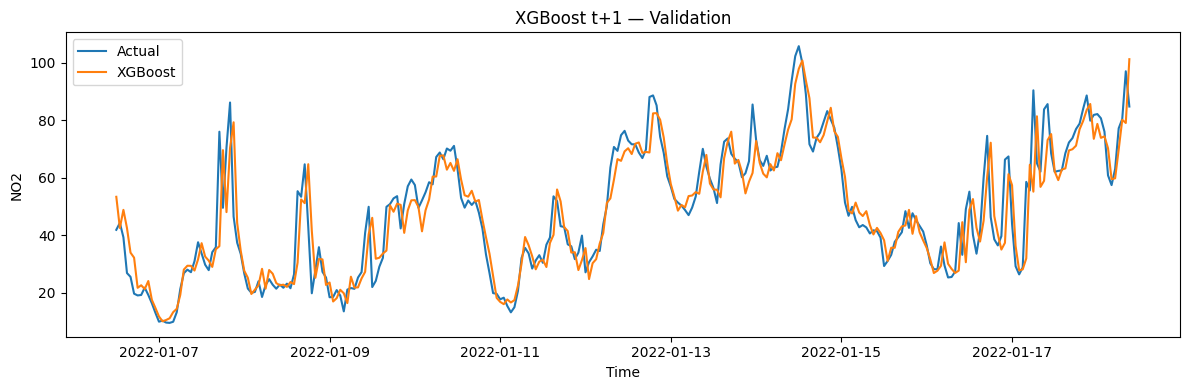

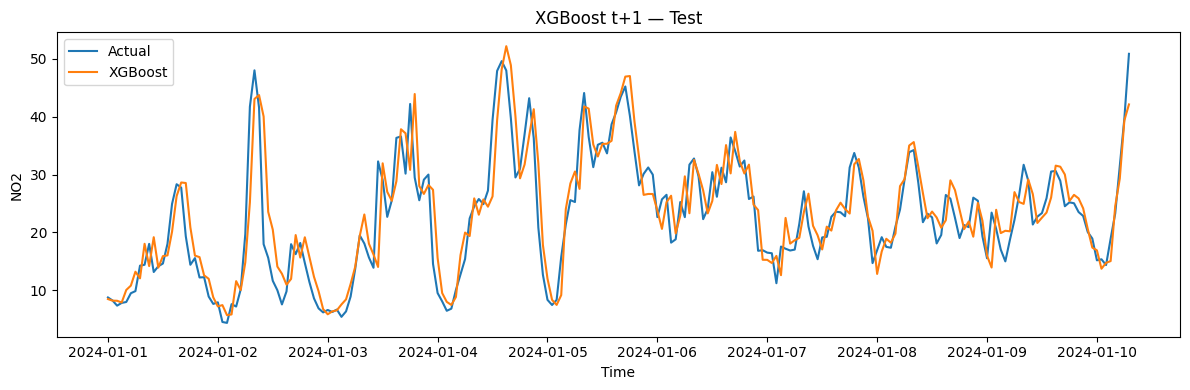

In [ ]:

# XGBoost prediction curves
N = 500

plot_gap_safe(
    val_sup.index[:N],
    y_val_xgb.iloc[:N].to_numpy(),
    pred_val_xgb[:N],
    title="XGBoost t+1 — Validation",
    pred_label="XGBoost",
    contiguous_only=True
)

plot_gap_safe(
    test_sup.index[:N],
    y_test_xgb.iloc[:N].to_numpy(),
    pred_test_xgb[:N],
    title="XGBoost t+1 — Test",
    pred_label="XGBoost",
    contiguous_only=True
)


###8.6 Learning Curve


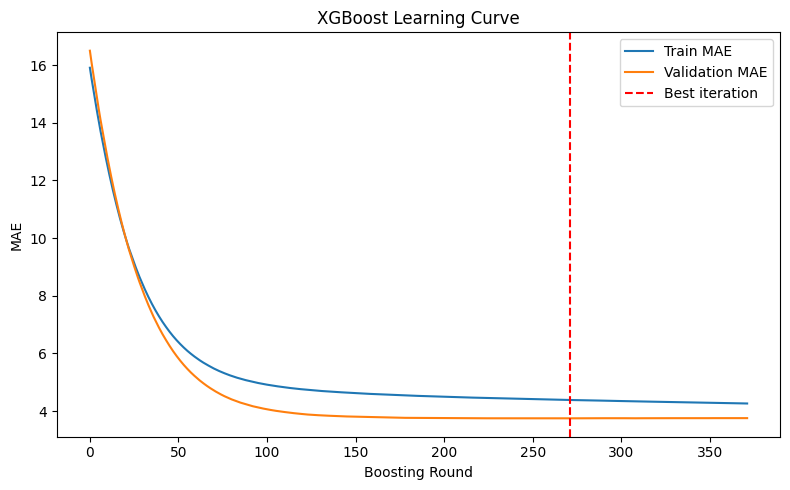

In [ ]:
train_mae_curve = final_evals["train"]["mae"]
val_mae_curve   = final_evals["val"]["mae"]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_mae_curve, label="Train MAE")
plt.plot(val_mae_curve, label="Validation MAE")
plt.axvline(final_booster.best_iteration, linestyle="--", color="red", label="Best iteration")
plt.legend()
plt.title("XGBoost Learning Curve")
plt.xlabel("Boosting Round")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

### 9.LSTM Model

### 9.1 Feature scaling
Scaling is fit on the **training split only**. Missing rows remain in place so that the sequence builder can identify and respect real discontinuities when constructing LSTM windows.


In [ ]:
# ============================================================
# 9.1 SCALE (fit on TRAIN only)
# ============================================================

X_FEATURE_COLS = [c for c in train_lstm_df.columns if c != TARGET_COL]

feature_scaler = RobustScaler()
target_scaler  = RobustScaler()

feature_scaler.fit(train_lstm_df[X_FEATURE_COLS].dropna().values)
target_scaler.fit(train_lstm_df[[TARGET_COL]].dropna().values)

def transform_split(df_split: pd.DataFrame) -> pd.DataFrame:
    Xs = pd.DataFrame(index=df_split.index, columns=X_FEATURE_COLS, dtype=float)
    ys = pd.Series(index=df_split.index, dtype=float, name=TARGET_COL)

    mX = df_split[X_FEATURE_COLS].notna().all(axis=1)
    if mX.any():
        Xs.loc[mX, X_FEATURE_COLS] = feature_scaler.transform(df_split.loc[mX, X_FEATURE_COLS].values)

    my = df_split[TARGET_COL].notna()
    if my.any():
        ys.loc[my] = target_scaler.transform(df_split.loc[my, [TARGET_COL]].values).ravel()

    out = Xs.copy()
    out[TARGET_COL] = ys
    return out

train_scaled_df = transform_split(train_lstm_df)
val_scaled_df   = transform_split(val_lstm_df)
test_scaled_df  = transform_split(test_lstm_df)

### 9.2 Sequence builder (contiguous segments only)
Each LSTM input window contains the last **WINDOW** rows **up to and including the current forecast origin (time t)**.

Because an LSTM requires **continuous hourly sequences**, windows are now built **separately within contiguous valid segments only**. A new segment starts whenever:

- there is a timestamp jump larger than 1 hour, or
- one or more required feature/target values are missing.

This prevents the LSTM from accidentally treating rows on opposite sides of a long gap as if they were adjacent in time.


In [ ]:
# ============================================================
# 9.2 SEQUENCE BUILDER (contiguous valid segments only)
# ============================================================
def build_valid_contiguous_segments(scaled_df, feature_cols, target_col, expected_freq="h"):
    """Return a copy of scaled_df with a segment_id over contiguous *valid* runs.

    A row is valid only if all required feature columns and the target are present.
    A new segment starts whenever:
      1) the timestamp jump is larger than the expected hourly step, or
      2) validity is broken by missing values.
    """
    df = scaled_df.copy().sort_index()
    expected = pd.Timedelta(hours=1) if str(expected_freq).lower() in ["h", "1h", "hour"] else pd.to_timedelta(expected_freq)

    valid_mask = df[feature_cols + [target_col]].notna().all(axis=1)
    df["_valid_row"] = valid_mask

    segment_ids = np.full(len(df), np.nan)
    current_seg = -1
    prev_valid_time = None

    for pos, (ts, is_valid) in enumerate(zip(df.index, valid_mask.to_numpy())):
        if not is_valid:
            prev_valid_time = None
            continue

        start_new = (
            prev_valid_time is None or
            (ts - prev_valid_time) > expected
        )
        if start_new:
            current_seg += 1

        segment_ids[pos] = current_seg
        prev_valid_time = ts

    df["segment_id"] = pd.Series(segment_ids, index=df.index).astype("Int64")
    return df


def make_sequences_by_segment(segmented_df, window, feature_cols, target_col):
    X_list, y_list, idx_list = [], [], []
    segment_meta = []

    usable = segmented_df.dropna(subset=["segment_id"]).copy()

    for seg_id, seg in usable.groupby("segment_id", sort=True):
        seg = seg.sort_index()

        # segment already contains only rows with complete features+target
        if len(seg) < window:
            continue

        vals_X = seg[feature_cols].to_numpy(dtype=np.float32)
        vals_y = seg[target_col].to_numpy(dtype=np.float32)

        # window ends at current forecast-origin row t
        for t in range(window - 1, len(seg)):
            X_list.append(vals_X[t - window + 1:t + 1])
            y_list.append(vals_y[t])
            idx_list.append(seg.index[t])
            segment_meta.append(int(seg_id))

    return (
        np.asarray(X_list, dtype=np.float32),
        np.asarray(y_list, dtype=np.float32),
        pd.DatetimeIndex(idx_list),
        np.asarray(segment_meta, dtype=np.int32),
    )


def summarise_segments(segmented_df, label):
    usable = segmented_df.dropna(subset=["segment_id"]).copy()
    if usable.empty:
        print(f"{label}: no usable contiguous segments.")
        return pd.DataFrame(columns=["rows", "start", "end", "duration_h"])
    summary = (
        usable.groupby("segment_id")
        .apply(lambda g: pd.Series({
            "rows": len(g),
            "start": g.index.min(),
            "end": g.index.max(),
            "duration_h": int((g.index.max() - g.index.min()) / pd.Timedelta(hours=1)) + 1,
        }))
        .sort_values(["rows", "start"], ascending=[False, True])
    )
    print(f"{label}: {len(summary)} usable contiguous segment(s).")
    display(summary.head(10))
    return summary


train_segmented_df = build_valid_contiguous_segments(train_scaled_df, X_FEATURE_COLS, TARGET_COL, expected_freq="h")
val_segmented_df   = build_valid_contiguous_segments(val_scaled_df,   X_FEATURE_COLS, TARGET_COL, expected_freq="h")
test_segmented_df  = build_valid_contiguous_segments(test_scaled_df,  X_FEATURE_COLS, TARGET_COL, expected_freq="h")

_ = summarise_segments(train_segmented_df, "Train")
_ = summarise_segments(val_segmented_df,   "Validation")
_ = summarise_segments(test_segmented_df,  "Test")


def make_lstm_data_for_window(window):
    X_train_seq, y_train_seq, idx_train_seq, seg_train_seq = make_sequences_by_segment(
        train_segmented_df, window, X_FEATURE_COLS, TARGET_COL
    )
    X_val_seq, y_val_seq, idx_val_seq, seg_val_seq = make_sequences_by_segment(
        val_segmented_df, window, X_FEATURE_COLS, TARGET_COL
    )
    X_test_seq, y_test_seq, idx_test_seq, seg_test_seq = make_sequences_by_segment(
        test_segmented_df, window, X_FEATURE_COLS, TARGET_COL
    )

    return {
        "window": window,
        "X_train_seq": X_train_seq,
        "y_train_seq": y_train_seq,
        "idx_train_seq": idx_train_seq,
        "seg_train_seq": seg_train_seq,
        "X_val_seq": X_val_seq,
        "y_val_seq": y_val_seq,
        "idx_val_seq": idx_val_seq,
        "seg_val_seq": seg_val_seq,
        "X_test_seq": X_test_seq,
        "y_test_seq": y_test_seq,
        "idx_test_seq": idx_test_seq,
        "seg_test_seq": seg_test_seq,
    }


# Default sequence build for the configured WINDOW, mainly for quick inspection.
seq_data_default = make_lstm_data_for_window(WINDOW)
X_train_seq = seq_data_default["X_train_seq"]
y_train_seq = seq_data_default["y_train_seq"]
idx_train_seq = seq_data_default["idx_train_seq"]
seg_train_seq = seq_data_default["seg_train_seq"]

X_val_seq = seq_data_default["X_val_seq"]
y_val_seq = seq_data_default["y_val_seq"]
idx_val_seq = seq_data_default["idx_val_seq"]
seg_val_seq = seq_data_default["seg_val_seq"]

X_test_seq = seq_data_default["X_test_seq"]
y_test_seq = seq_data_default["y_test_seq"]
idx_test_seq = seq_data_default["idx_test_seq"]
seg_test_seq = seq_data_default["seg_test_seq"]

print(f"Default WINDOW={WINDOW}")
print("Train sequences:", X_train_seq.shape, y_train_seq.shape)
print("Val sequences  :", X_val_seq.shape, y_val_seq.shape)
print("Test sequences :", X_test_seq.shape, y_test_seq.shape)

Train: 166 usable contiguous segment(s).


/tmp/ipykernel_8499/3083441129.py:79: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,rows,start,end,duration_h
segment_id,,,,
86,1702,2018-03-14 15:00:00,2018-05-24 12:00:00,1702
107,1540,2019-03-01 14:00:00,2019-05-04 17:00:00,1540
68,1342,2017-05-24 14:00:00,2017-07-19 11:00:00,1342
123,1331,2020-01-23 23:00:00,2020-03-19 09:00:00,1331
114,1322,2019-08-20 12:00:00,2019-10-14 13:00:00,1322
110,1290,2019-05-22 15:00:00,2019-07-15 08:00:00,1290
11,1282,2015-08-20 09:00:00,2015-10-12 18:00:00,1282
118,1159,2019-10-24 08:00:00,2019-12-11 14:00:00,1159
139,956,2020-11-26 12:00:00,2021-01-05 07:00:00,956


Validation: 53 usable contiguous segment(s).


/tmp/ipykernel_8499/3083441129.py:79: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,rows,start,end,duration_h
segment_id,,,,
10,1029,2022-06-15 09:00:00,2022-07-28 05:00:00,1029
46,699,2023-08-23 10:00:00,2023-09-21 12:00:00,699
40,672,2023-05-03 14:00:00,2023-05-31 13:00:00,672
36,670,2023-02-22 15:00:00,2023-03-22 12:00:00,670
37,670,2023-03-22 15:00:00,2023-04-19 12:00:00,670
41,665,2023-05-31 15:00:00,2023-06-28 07:00:00,665
9,646,2022-05-19 09:00:00,2022-06-15 06:00:00,646
48,583,2023-09-24 01:00:00,2023-10-18 07:00:00,583
23,550,2022-10-11 15:00:00,2022-11-03 12:00:00,550


Test: 51 usable contiguous segment(s).


/tmp/ipykernel_8499/3083441129.py:79: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,rows,start,end,duration_h
segment_id,,,,
6,1013,2024-03-06 10:00:00,2024-04-17 14:00:00,1013
9,718,2024-06-11 15:00:00,2024-07-11 12:00:00,718
19,693,2024-12-23 12:00:00,2025-01-21 08:00:00,693
10,673,2024-07-11 14:00:00,2024-08-08 14:00:00,673
7,670,2024-04-17 16:00:00,2024-05-15 13:00:00,670
15,669,2024-10-02 12:00:00,2024-10-30 08:00:00,669
24,668,2025-03-19 13:00:00,2025-04-16 08:00:00,668
14,666,2024-09-04 16:00:00,2024-10-02 09:00:00,666
29,656,2025-05-16 00:00:00,2025-06-12 07:00:00,656


Default WINDOW=48
Train sequences: (51127, 48, 11) (51127,)
Val sequences  : (13135, 48, 11) (13135,)
Test sequences : (14553, 48, 11) (14553,)


###9.3 Inverse Transforming

In [ ]:
# ============================================================
# 9.3 HELPERS
# ============================================================

def inv_target(y_scaled):
    return target_scaler.inverse_transform(np.asarray(y_scaled).reshape(-1,1)).ravel()

def mae_rmse_original(y_true_scaled, y_pred_scaled):
    y_true = inv_target(y_true_scaled)
    y_pred = inv_target(y_pred_scaled)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

## 9.4 Model Builder

In [ ]:
# ============================================================
# 9.4 MODEL BUILDER (tunable)
# Builds either a single-layer or stacked LSTM depending on
# the tuning choice, and compiles it with the selected loss.
def build_model(window_len, units=64, dropout=0.2, l2_strength=0.0, lr=1e-3, stacked=False, loss_name="huber"):
    tf.keras.backend.clear_session()

    # Optional L2 regularisation

    reg = regularizers.l2(l2_strength) if l2_strength and l2_strength > 0 else None

    model = Sequential()
    model.add(tf.keras.Input(shape=(window_len, len(X_FEATURE_COLS))))

    # Choose between single-layer and stacked LSTM

    if stacked:
        model.add(LSTM(
            units,
            return_sequences=True,
            kernel_regularizer=reg,
            recurrent_regularizer=reg
        ))
        model.add(Dropout(dropout))
        model.add(LSTM(
            max(16, units // 2),
            kernel_regularizer=reg,
            recurrent_regularizer=reg
        ))
    else:
        model.add(LSTM(
            units,
            kernel_regularizer=reg,
            recurrent_regularizer=reg
        ))

    model.add(Dropout(dropout))
    model.add(Dense(1, kernel_regularizer=reg))

   # Select the loss function to use during training


    if loss_name == "mse":
        loss_obj = "mse"
    elif loss_name == "mae":
        loss_obj = "mae"
    else:
        loss_obj = tf.keras.losses.Huber()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=loss_obj,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model

### 9.5 Hyperparameter Tuning (KerasTuner RandomSearch)

I used KerasTuner RandomSearch to tune the LSTM systematically rather than choosing parameters manually. The search covered window length, hidden units, dropout, L2 regularisation, learning rate, batch size, loss function, and whether the model should be single-layer or stacked. Validation performance on the chronological split was used to select the best configuration, while EarlyStopping and ReduceLROnPlateau were used to improve training stability and efficiency. This provided a structured and reproducible way to select the final LSTM settings.

In [ ]:
# ============================================================
# 10) HYPERPARAMETER TUNING WITH KERASTUNER (FAST VERSION)
#     Tune on validation MAE of the scaled residual target.
#     Because RobustScaler is linear, minimising scaled MAE is
#     equivalent to minimising MAE in original units up to a constant.
# ============================================================
TUNER_WINDOW = WINDOW
TUNE_EPOCHS = 18
TUNE_PATIENCE = 4
MAX_TRIALS = 8
OVERWRITE_TUNER = True

seq_data_tune = make_lstm_data_for_window(TUNER_WINDOW)

X_train_seq_tune = seq_data_tune["X_train_seq"]
y_train_seq_tune = seq_data_tune["y_train_seq"]
X_val_seq_tune   = seq_data_tune["X_val_seq"]
y_val_seq_tune   = seq_data_tune["y_val_seq"]

if len(X_train_seq_tune) == 0 or len(X_val_seq_tune) == 0:
    raise ValueError("No valid sequences for tuner. Try a smaller TUNER_WINDOW.")

print(f"TUNER_WINDOW={TUNER_WINDOW}")
print("Train sequences:", X_train_seq_tune.shape, y_train_seq_tune.shape)
print("Val sequences  :", X_val_seq_tune.shape, y_val_seq_tune.shape)

class LSTMHyperModel(kt.HyperModel):
    def build(self, hp):
        units = hp.Choice("units", [64, 96, 128])
        dropout = hp.Choice("dropout", [0.0, 0.1])
        l2_strength = hp.Choice("l2", [0.0, 1e-6])
        lr = hp.Choice("lr", [1e-3, 5e-4])
        stacked = hp.Choice("stacked", [False, True])
        loss_name = hp.Choice("loss", ["huber", "mae"])

        return build_model(
            window_len=TUNER_WINDOW,
            units=units,
            dropout=dropout,
            l2_strength=l2_strength,
            lr=lr,
            stacked=stacked,
            loss_name=loss_name
        )

    def fit(self, hp, model, *args, **kwargs):
        batch_size = hp.Choice("batch", [32, 64])
        return model.fit(*args, batch_size=batch_size, **kwargs)

tuner = kt.RandomSearch(
    hypermodel=LSTMHyperModel(),
    objective=kt.Objective("val_mae", direction="min"),
    max_trials=MAX_TRIALS,
    seed=SEED,
    overwrite=OVERWRITE_TUNER,
    directory="kt_lstm_no2_fast",
    project_name=f"window_{TUNER_WINDOW}"
)

reduce_lr_tune = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)
early_stop_tune = EarlyStopping(
    monitor="val_loss",
    patience=TUNE_PATIENCE,
    restore_best_weights=True
)

tuner.search(
    X_train_seq_tune,
    y_train_seq_tune,
    validation_data=(X_val_seq_tune, y_val_seq_tune),
    epochs=TUNE_EPOCHS,
    shuffle=False,
    verbose=1,
    callbacks=[reduce_lr_tune, early_stop_tune]
)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_params = {
    "window": TUNER_WINDOW,
    "units": best_hp.get("units"),
    "dropout": best_hp.get("dropout"),
    "l2": best_hp.get("l2"),
    "lr": best_hp.get("lr"),
    "batch": best_hp.get("batch"),
    "stacked": best_hp.get("stacked"),
    "loss": best_hp.get("loss"),
}

print("\n=== KERASTUNER BEST LSTM CONFIG ===")
for k, v in best_params.items():
    print(f"{k}: {v}")

# quick validation check in original units using the best tuner model
best_tuned_model = tuner.get_best_models(num_models=1)[0]
pred_val_scaled_tmp = best_tuned_model.predict(X_val_seq_tune, verbose=0).ravel()
val_mae_tmp, val_rmse_tmp = mae_rmse_original(y_val_seq_tune, pred_val_scaled_tmp)
print(f"Validation MAE (orig units): {val_mae_tmp:.4f}")
print(f"Validation RMSE (orig units): {val_rmse_tmp:.4f}")

Trial 8 Complete [00h 04m 26s]
val_mae: 0.12263147532939911

Best val_mae So Far: 0.12179165333509445
Total elapsed time: 00h 25m 29s

=== KERASTUNER BEST LSTM CONFIG ===
window: 48
units: 96
dropout: 0.0
l2: 0.0
lr: 0.001
batch: 64
stacked: 1
loss: mae


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Validation MAE (orig units): 3.4952
Validation RMSE (orig units): 5.2909


### 9.6 Final Training (best KerasTuner configuration)

In [ ]:
# ============================================================
# 11) FINAL TRAINING (best params, longer training)
# ============================================================
FINAL_EPOCHS = 50
FINAL_PATIENCE = 8

best_window = best_params["window"]
seq_data = make_lstm_data_for_window(best_window)

X_train_seq = seq_data["X_train_seq"]
y_train_seq = seq_data["y_train_seq"]
idx_train_seq = seq_data["idx_train_seq"]
seg_train_seq = seq_data["seg_train_seq"]

X_val_seq = seq_data["X_val_seq"]
y_val_seq = seq_data["y_val_seq"]
idx_val_seq = seq_data["idx_val_seq"]
seg_val_seq = seq_data["seg_val_seq"]

X_test_seq = seq_data["X_test_seq"]
y_test_seq = seq_data["y_test_seq"]
idx_test_seq = seq_data["idx_test_seq"]
seg_test_seq = seq_data["seg_test_seq"]

print(f"Using best KerasTuner window={best_window}")
print("Train sequences:", X_train_seq.shape, y_train_seq.shape)
print("Val sequences  :", X_val_seq.shape, y_val_seq.shape)
print("Test sequences :", X_test_seq.shape, y_test_seq.shape)

tf.random.set_seed(SEED)
np.random.seed(SEED)

final_model = build_model(
    window_len=best_window,
    units=best_params["units"],
    dropout=best_params["dropout"],
    l2_strength=best_params["l2"],
    lr=best_params["lr"],
    stacked=best_params["stacked"],
    loss_name=best_params["loss"]
)

reduce_lr_final = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1)
early_stop_final = EarlyStopping(monitor="val_loss", patience=FINAL_PATIENCE, restore_best_weights=True)

history = final_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=FINAL_EPOCHS,
    batch_size=best_params["batch"],
    shuffle=False,
    verbose=1,
    callbacks=[reduce_lr_final, early_stop_final]
)

Using best KerasTuner window=48
Train sequences: (51127, 48, 11) (51127,)
Val sequences  : (13135, 48, 11) (13135,)
Test sequences : (14553, 48, 11) (14553,)
Epoch 1/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.2357 - mae: 0.2357 - val_loss: 0.1420 - val_mae: 0.1420 - learning_rate: 0.0010
Epoch 2/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.1718 - mae: 0.1718 - val_loss: 0.1330 - val_mae: 0.1330 - learning_rate: 0.0010
Epoch 3/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.1684 - mae: 0.1684 - val_loss: 0.1324 - val_mae: 0.1324 - learning_rate: 0.0010
Epoch 4/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.1665 - mae: 0.1665 - val_loss: 0.1298 - val_mae: 0.1298 - learning_rate: 0.0010
Epoch 5/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.1662 - mae: 0.1662 - val_loss: 0.1282 - val_mae: 0.1282 - learning_rate: 0.0010
Epoch 6/50
799/799 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.1653 - mae: 0.1653 - val_loss: 0.1311 - val_mae: 0.1311 - learning_r

### 9.7 Evaluation

In [ ]:
# ============================================================
# 12) EVALUATION (original units)
# ============================================================
pred_val_scaled_lstm  = final_model.predict(X_val_seq,  verbose=0).ravel()
pred_test_scaled_lstm = final_model.predict(X_test_seq, verbose=0).ravel()

val_mae_lstm, val_rmse_lstm   = mae_rmse_original(y_val_seq,  pred_val_scaled_lstm)
test_mae_lstm, test_rmse_lstm = mae_rmse_original(y_test_seq, pred_test_scaled_lstm)

print("\n=== FINAL LSTM ===")
print("Best params:", best_params)
print(f"Validation MAE : {val_mae_lstm:.4f}")
print(f"Validation RMSE: {val_rmse_lstm:.4f}")
print(f"Test MAE       : {test_mae_lstm:.4f}")
print(f"Test RMSE      : {test_rmse_lstm:.4f}")



=== FINAL LSTM ===
Best params: {'window': 48, 'units': 96, 'dropout': 0.0, 'l2': 0.0, 'lr': 0.001, 'batch': 64, 'stacked': 1, 'loss': 'mae'}
Validation MAE : 3.5373
Validation RMSE: 5.3198
Test MAE       : 3.2418
Test RMSE      : 4.8441


### 9.7 Prediction Curve

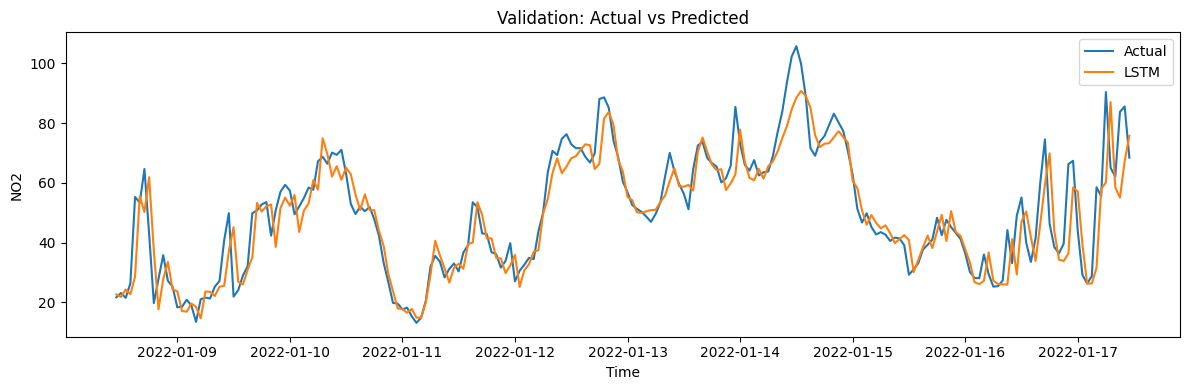

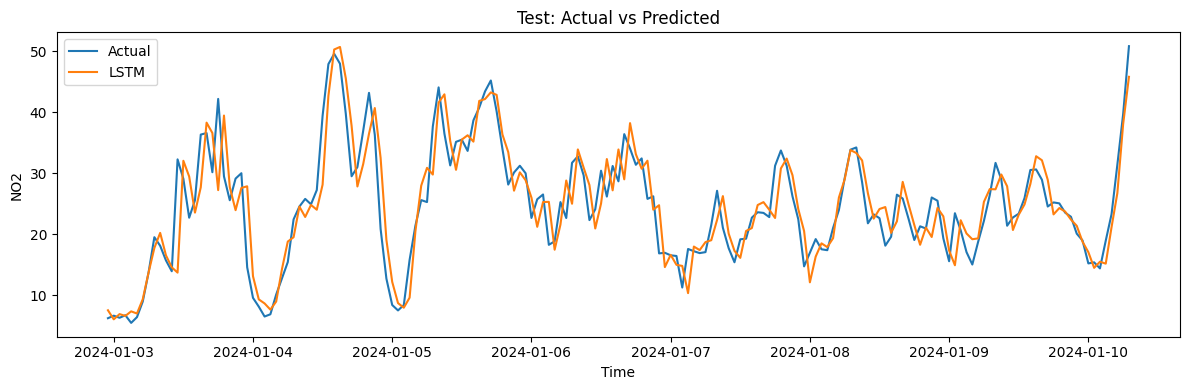

In [ ]:

# ============================================================
# 13) Prediction Plots (gap-safe; longest contiguous block)
# ============================================================
# Inverse-transform true and predicted values
y_val_true_lstm  = inv_target(y_val_seq)
y_test_true_lstm = inv_target(y_test_seq)

y_val_pred_lstm  = inv_target(pred_val_scaled_lstm)
y_test_pred_lstm = inv_target(pred_test_scaled_lstm)

# Validation plot
N = min(300, len(y_val_true_lstm))
plot_gap_safe(
    idx_val_seq[:N],
    y_val_true_lstm[:N],
    y_val_pred_lstm[:N],
    title="Validation: Actual vs Predicted",
    pred_label="LSTM",
    contiguous_only=True
)

# Test plot
N = min(300, len(y_test_true_lstm))
plot_gap_safe(
    idx_test_seq[:N],
    y_test_true_lstm[:N],
    y_test_pred_lstm[:N],
    title="Test: Actual vs Predicted",
    pred_label="LSTM",
    contiguous_only=True
)


## 9.8 Loss Curve

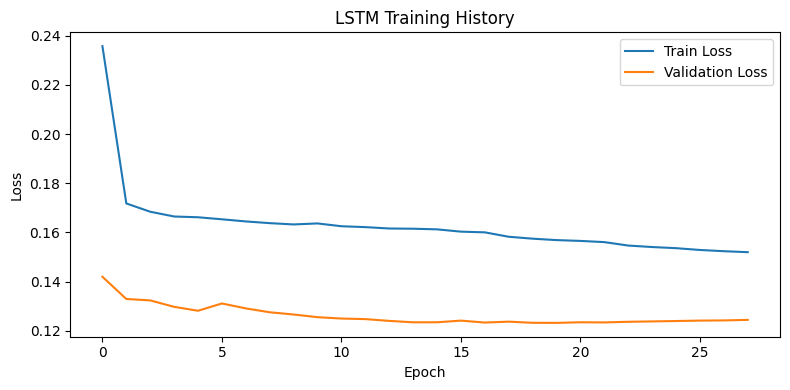

In [ ]:
# ============================================================
# Training History Plot
# ============================================================

hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(8,4))
plt.plot(hist_df["loss"], label="Train Loss")
plt.plot(hist_df["val_loss"], label="Validation Loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

,train,val,test
count,56172.00,14462.00,16432.00
mean,35.88,24.01,22.59
std,20.17,15.07,13.35
p95,72.81,54.36,49.31
p99,91.80,73.19,64.31
max,157.65,105.71,97.63


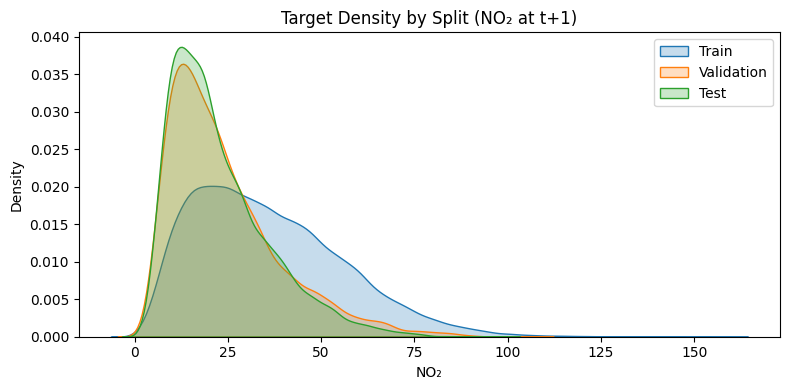

In [ ]:
# ============================================================
# 15) Target distribution shift summary
# ============================================================
def split_stats(y, name):
    return pd.Series({
        "count": y.count(),
        "mean": y.mean(),
        "std": y.std(),
        "p95": y.quantile(0.95),
        "p99": y.quantile(0.99),
        "max": y.max()
    }, name=name)

stats = pd.concat([
    split_stats(train_sup[TARGET_COL], "train"),
    split_stats(val_sup[TARGET_COL], "val"),
    split_stats(test_sup[TARGET_COL], "test"),
], axis=1)

display(stats.round(2))

plt.figure(figsize=(8,4))
sns.kdeplot(train_sup[TARGET_COL].dropna(), label="Train", fill=True)
sns.kdeplot(val_sup[TARGET_COL].dropna(), label="Validation", fill=True)
sns.kdeplot(test_sup[TARGET_COL].dropna(), label="Test", fill=True)

plt.title("Target Density by Split (NO₂ at t+1)")
plt.xlabel("NO₂")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()
